In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob

In [2]:
files = glob.glob(r"D:\Graduation Project\attack classifier\Data/*csv")

In [3]:
df = pd.concat([pd.read_csv(f) for f in files], ignore_index= True)

In [4]:
df.shape

(2830743, 79)

In [5]:
df.dropna(inplace=True)
print(df["Flow Bytes/s"].isna().sum() / len(df) * 100)

0.0


In [6]:
df = df[~np.isinf(df["Flow Bytes/s"])]
df = df[~np.isinf(df[" Flow Packets/s"])]
print(df["Flow Bytes/s"].isin([float('inf'), float('-inf')]).sum() / len(df) * 100)
print(df[" Flow Packets/s"].isin([float('inf'), float('-inf')]).sum()/df[" Flow Packets/s"].count() * 100)

0.0
0.0


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [9]:
df.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [10]:
df.shape

(2520798, 79)

In [11]:
df[" Label"].value_counts()

 Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

<Axes: xlabel='count', ylabel=' Label'>

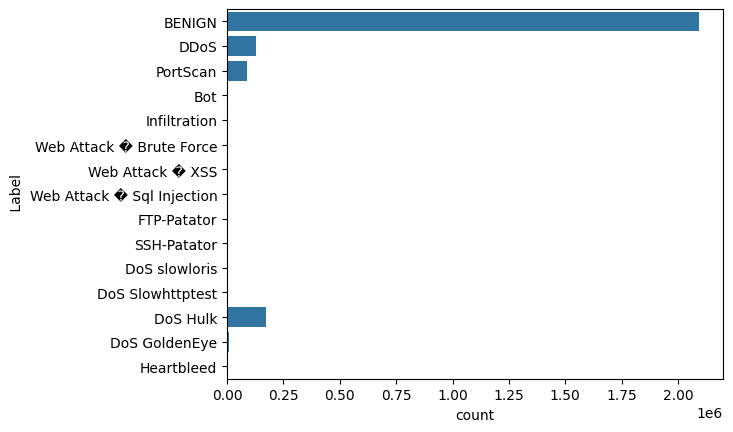

In [12]:
sns.countplot(df[" Label"])

In [13]:
for label in df[' Label'].unique():
    if 'Web' in str(label):
        print(repr(label))

'Web Attack � Brute Force'
'Web Attack � XSS'
'Web Attack � Sql Injection'


In [14]:
df[' Label'] = df[' Label'].str.replace(r'Web Attack.*Brute Force', 'Brute Force', regex=True)
df[' Label'] = df[' Label'].str.replace(r'Web Attack.*XSS', 'XSS', regex=True)
df[' Label'] = df[' Label'].str.replace(r'Web Attack.*Sql Injection', 'Sql Injection', regex=True)

keep_labels = [
    'BENIGN',
    'DoS Hulk',
    'DDoS',
    'PortScan',
    'DoS GoldenEye',
    'FTP-Patator',
    'DoS slowloris',
    'DoS Slowhttptest',
    'Brute Force'
]

df = df[df[' Label'].isin(keep_labels)]

mapping = {
    "BENIGN":"BENIGN",
    "DoS Hulk":"DDos",
    "DDoS":"DDos",
    "PortScan":"PortScan",
    "DoS GoldenEye" :"DDos",
    "FTP-Patator":"FTP-Patator",
    "DoS slowloris":"DDos",
    "DoS Slowhttptest":"DDos",
    "Brute Force":"Brute Force"
}

df[" Label"] = df[" Label"].map(mapping)


In [15]:
df[" Label"].value_counts()

 Label
BENIGN         2095057
DDos            321759
PortScan         90694
FTP-Patator       5931
Brute Force       1470
Name: count, dtype: int64

In [16]:
df.drop(columns=[' Fwd Header Length.1'], inplace=True)

In [17]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

df.columns = df.columns.str.strip()

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

le = LabelEncoder()
y = le.fit_transform(df['Label'])
X = df.drop(columns=['Label'])

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        objective='multi:softmax',
        num_class=len(le.classes_),
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
        tree_method = 'hist'
    ))
])


In [21]:
pd.DataFrame(y).value_counts()

0
0    2095057
2     321759
4      90694
3       5931
1       1470
Name: count, dtype: int64

In [ ]:
from sklearn.model_selection import cross_validate ,StratifiedKFold
import numpy as np

cv_results = cross_validate(
    pipeline,
    X_train, y_train,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring=['accuracy', 'f1_weighted', 'f1_macro'],
    n_jobs=1,
    verbose=1
)

print("Cross Validation Results:")
print(f"Accuracy:    {np.mean(cv_results['test_accuracy']):.4f} ± {np.std(cv_results['test_accuracy']):.4f}")
print(f"F1 Weighted: {np.mean(cv_results['test_f1_weighted']):.4f} ± {np.std(cv_results['test_f1_weighted']):.4f}")
print(f"F1 Macro:    {np.mean(cv_results['test_f1_macro']):.4f} ± {np.std(cv_results['test_f1_macro']):.4f}")

Cross Validation Results:
Accuracy:    0.9994 ± 0.0001
F1 Weighted: 0.9994 ± 0.0001
F1 Macro:    0.9964 ± 0.0008


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:  3.9min finished


In [ ]:
# Get one row from each class to test
for label in le.classes_:
    # find first row of this class in test set
    idx = (y_test == le.transform([label])[0]).argmax()
    row = X_test[idx]
    print(f"\n--- {label} ---")
    print(dict(zip(feature_names, row)))

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    419012
 Brute Force       0.99      0.99      0.99       294
        DDos       1.00      1.00      1.00     64352
 FTP-Patator       1.00      1.00      1.00      1186
    PortScan       0.99      1.00      0.99     18139

    accuracy                           1.00    502983
   macro avg       1.00      1.00      1.00    502983
weighted avg       1.00      1.00      1.00    502983



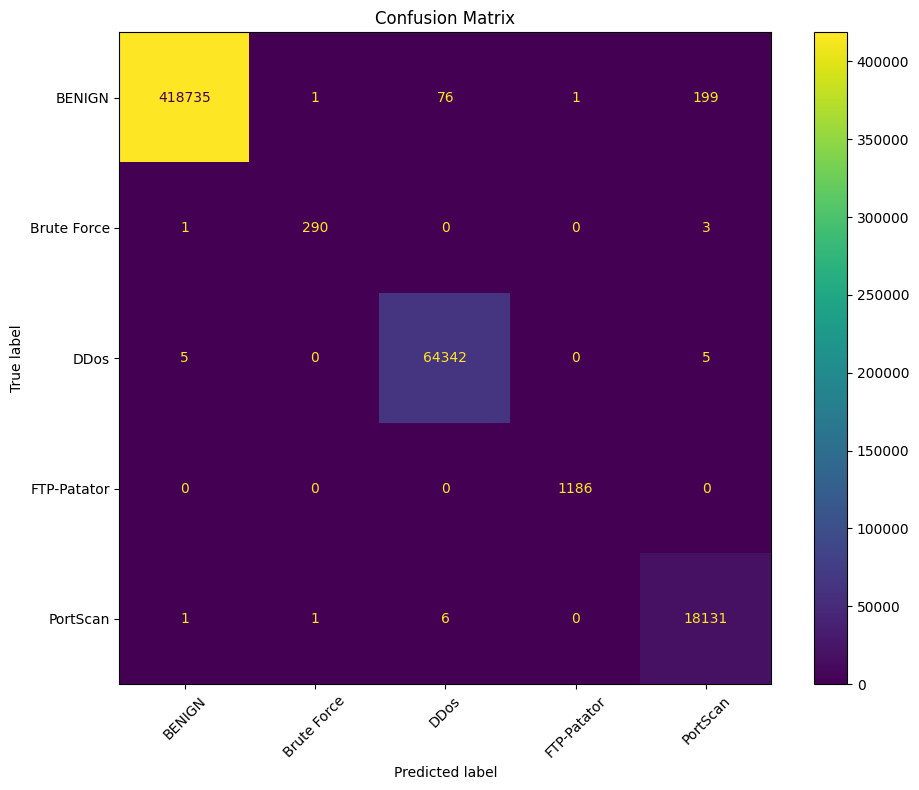

In [ ]:

pipeline.fit(X_train, y_train, model__sample_weight=sample_weights)

y_pred = pipeline.predict(X_test)

# Evaluation
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_,
    ax=ax,
    xticks_rotation=45
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
import joblib
joblib.dump({
    "model1": pipeline,
    "label_encoder": le,
    "feature_names": X.columns.tolist()
}, "model.pkl")

['model.pkl']